# Визначення пневмонії за рентген-знімками
## Бізнес-контекст
Компанія MediScan AI впроваджує модель, яка за рентген-знімками грудної клітки визначає наявність пневмонії.
Вам необхідно створити і навчити таку модель, використовуючи transfer learning і методи регуляризації.
## Завдання 1
Підготуйте датасет Chest X-Ray Pneumonia.
- Завантажте зображення.
- Виконайте resize (224×224) і нормалізацію.
- Розділіть дані на train/test.

*Завантажуємо дані з https://www.kaggle.com/datasets/ghost5612/chest-x-ray-images-normal-and-pneumonia?resource=download та розпаковуємо архів до директорії ./data*

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = './data/chest_xray'
subdirs = ['test', 'train', 'val']
mean = [0.485, 0.485, 0.485]
std  = [0.229, 0.229, 0.229]

transform = transforms.Compose([
    transforms.Resize( (224, 224) ),
    transforms.ToTensor(),
    transforms.Normalize( mean, std )   # для кольорових зображень по три параметри (RGB)
])

img_datasets = {
    s: datasets.ImageFolder(root=f"{data_dir}/{s}", transform=transform)
    for s in subdirs
}

dataloaders = {
    s: DataLoader(img_datasets[s], batch_size=32, shuffle=(s=='train'), num_workers=4)
    for s in subdirs
}

class_names = img_datasets[ subdirs[0] ].classes
print(class_names)

['NORMAL', 'PNEUMONIA']


In [3]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img) :
    img = np.transpose(img.numpy(), (1,2,0))  # Перетворюємо тензори з кольорами на послідовність двомірних точок
    img = img * std + mean  # Денормалізація - множимо на дисперсію та додаємо середнє
    img = img.clip(0,1)  # Обмежуємо вихід кольору за межі 0-1
    plt.imshow(img)
    plt.axis('off')
    plt.show()

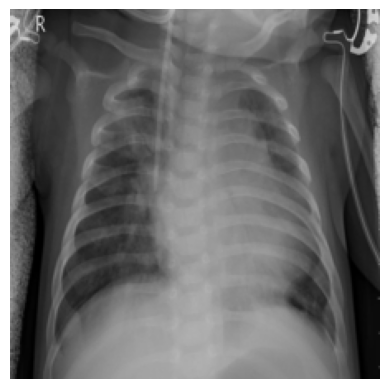

In [4]:
images, labels = next( iter(dataloaders['train']) )
imshow( images[0] )

## Завдання 2
Використовуйте переднавчену модель ResNet18.
- Заморозьте згорткові шари.
- Замініть класифікатор на новий (Linear(512, 2)).
- Функція втрат: CrossEntropyLoss.
- Оптимізатор: Adam (lr=0.0001).
- Навчіть 5 епох.

In [6]:
# Використовуйте переднавчену модель ResNet18.
import torchvision
resnet18 = torchvision.models.resnet18(weights='DEFAULT') 

In [7]:
# Заморозьте згорткові шари.
for param in resnet18.parameters():
    param.requires_grad = False

# Замініть класифікатор на новий (Linear(512, 2)).
# визначаємо розмірність передостаннього шару
num_features = resnet18.fc.in_features
# замінюємо його на новий з виходом 2 (і не замороженими градієнтами)
resnet18.fc = torch.nn.Linear(num_features, 2)
print(num_features)

512


In [8]:
# Функція втрат: CrossEntropyLoss.
loss_f = torch.nn.CrossEntropyLoss()
# Оптимізатор: Adam (lr=0.0001).
optimizer = torch.optim.Adam(resnet18.parameters(), lr=0.0001)

In [ ]:
# epochs = 5
# for epoch in range(epochs):
#     with torch.no_grad():
#         for images, labels in dataloaders['train']:
#             _, pred = torch.max(resnet18(images), 1)
#             